<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-3-experiment-1/brfss_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Baseline Algorithm Comparison (CDC BRFSS)

This notebook trains and compares three baseline machine learning models on the **raw, unbalanced CDC BRFSS dataset**:

1. Logistic Regression  
2. LightGBM  
3. XGBoost  

The purpose of this experiment is to establish baseline performance before applying any balancing techniques such as SMOTE.

## Evaluation Metrics
The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC

## Dataset
- **Dataset:** CDC BRFSS Diabetes Health Indicators
- **Target column:** `Diabetes_binary`

## Notes
- The dataset remains **unbalanced** in this experiment.
- A **stratified 80/20 train-test split** is used.
- **Feature scaling** is applied only for Logistic Regression.

In [9]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 372, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 372 (delta 58), reused 15 (delta 15), pack-reused 256 (from 4)
Receiving objects: 100% (372/372), 9.89 MiB | 23.39 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [10]:
import os
os.chdir("/content/Predicting-Type-2-Diabetes")
print("Current working directory:", os.getcwd())

Current working directory: /content/Predicting-Type-2-Diabetes


In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [12]:
os.makedirs("results", exist_ok=True)
print("Results folder ready.")

Results folder ready.


In [13]:
df = pd.read_csv("data/raw/diabetes_binary_health_indicators_BRFSS2015.csv")

print("CDC BRFSS dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

CDC BRFSS dataset loaded successfully.
Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution (count):")
print(df["Diabetes_binary"].value_counts())

print("\nTarget distribution (%):")
print(df["Diabetes_binary"].value_counts(normalize=True) * 100)

Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:
0

Duplicate rows:
24206

Target distribution (count):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Target distribution (%):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


In [15]:
class_counts = df["Diabetes_binary"].value_counts().sort_index()
no_diabetes = class_counts[0]
diabetes = class_counts[1]

no_diabetes_pct = (no_diabetes / len(df)) * 100
diabetes_pct = (diabetes / len(df)) * 100
imbalance_ratio = no_diabetes / diabetes

print("Imbalance Severity Note")
print(f"No Diabetes (0): {no_diabetes:,} ({no_diabetes_pct:.2f}%)")
print(f"Diabetes (1): {diabetes:,} ({diabetes_pct:.2f}%)")
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

Imbalance Severity Note
No Diabetes (0): 218,334 (86.07%)
Diabetes (1): 35,346 (13.93%)
Majority-to-minority ratio: 6.18:1


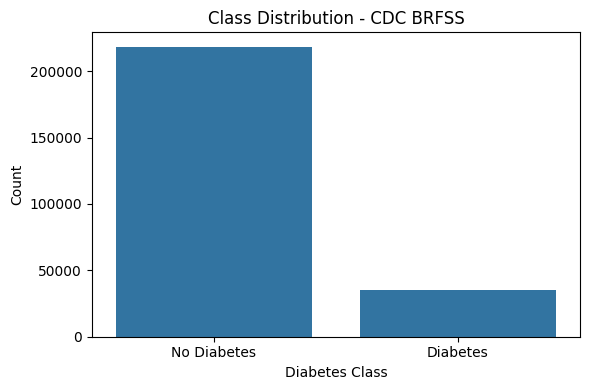

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes_binary", data=df)
plt.title("Class Distribution - CDC BRFSS")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.tight_layout()
plt.savefig("results/brfss_class_distribution_baseline.png", dpi=150)
plt.show()